In [222]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from numpy import loadtxt
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import activations
from tensorflow.keras.metrics import AUC
from keras import regularizers
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from scikeras.wrappers import KerasClassifier

keras.utils.set_random_seed(812)

In [212]:
data = pd.read_csv('data/train_data.csv')
data

,ID,Bankruptcy,Realized.Sales.Gross.Profit.Growth.Rate,Operating.Expense.Rate,Operating.Profit.Per.Share..Yuan...,Gross.Profit.to.Sales,Tax.rate..A.,Current.Liability.to.Liability,Continuous.Net.Profit.Growth.Rate,Long.term.Liability.to.Current.Assets,...,Per.Share.Net.profit.before.tax..Yuan...,Continuous.interest.rate..after.tax.,Liability.Assets.Flag,Working.Capital.to.Total.Assets,Degree.of.Financial.Leverage..DFL.,Operating.Gross.Margin,Contingent.liabilities.Net.worth,Operating.Profit.Growth.Rate,Cash.Flow.to.Liability,Quick.Assets.Total.Assets
0,1,0,0.087661,1.900349e-04,0.131094,0.583345,0.000000,0.815892,0.395719,0.089276,...,0.223720,0.801737,0,0.839112,0.036551,0.591350,0.007401,0.913175,0.489822,0.138714
1,2,0,0.021892,5.371576e-04,0.086167,0.695478,0.209649,0.768636,0.163505,0.000000,...,0.324763,0.791203,0,0.908450,0.126752,0.766066,0.020514,0.849241,0.550247,0.704211
2,3,0,0.102249,2.178329e-04,0.157755,0.766934,0.272061,0.643316,0.181571,0.010180,...,0.360892,0.803126,0,0.865943,0.018152,0.687211,0.004363,0.865814,0.447168,0.398086
3,4,0,0.029972,4.915756e+10,0.249279,0.611580,0.288357,0.752782,0.409196,0.018603,...,0.152445,0.824732,0,0.806254,0.051284,0.715973,0.014162,0.843357,0.485163,0.617386
4,6,0,0.021164,1.206001e-04,0.239817,0.614250,0.000000,0.559498,0.286989,0.148687,...,0.217282,0.787010,0,0.769843,0.012872,0.704043,0.003050,0.884905,0.422001,0.187121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2045,2545,0,0.067900,7.201851e+05,0.334972,0.564459,0.166696,0.889719,0.277489,0.005494,...,0.177566,0.793529,0,0.860448,0.020242,0.720086,0.006337,0.867445,0.443956,0.699702
2046,2546,0,0.067735,2.380508e-05,0.193017,0.736555,0.089094,0.738665,0.348624,0.007731,...,0.383780,0.830696,0,0.842840,0.159408,0.603963,0.025980,0.824779,0.550102,0.551980
2047,2547,0,0.068447,8.325822e-05,0.109198,0.734305,0.000000,0.534512,0.404424,0.029523,...,0.265202,0.757833,0,0.759694,0.026616,0.741242,0.007079,0.876836,0.666202,0.311649
2048,2548,0,0.017600,9.098720e-03,0.279550,0.757877,0.492404,0.806436,0.175130,0.014910,...,0.380793,0.799704,0,0.791138,0.136190,0.656832,0.003518,0.900142,0.471446,0.401341


In [213]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,2:], data.iloc[:,1], test_size=0.20, random_state=10)

print(f'Train size: {X_train.shape}')
print(f'Test size: {X_test.shape}')

Train size: (1640, 63)
Test size: (410, 63)


In [214]:
print(f'Train cases: {y_train.value_counts()}')
print(f'Test cases: {y_test.value_counts()}')

Train cases: Bankruptcy
0    1588
1      52
Name: count, dtype: int64
Test cases: Bankruptcy
0    400
1     10
Name: count, dtype: int64


In [215]:

# 1. Transformador para manejar outliers
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
        self.means_ = None
        self.stds_ = None
        self.is_numeric_ = None
        
    def fit(self, X, y=None):
        self.is_numeric_ = {col: np.issubdtype(X[col].dtype, np.number) 
                            for col in X.columns}
        self.means_ = {}
        self.stds_ = {}
        
        for col in X.columns:
            if self.is_numeric_[col]:
                lower = X[col].quantile(0.01)
                upper = X[col].quantile(0.98)
                filtered = X[col][(X[col] >= lower) & (X[col] <= upper)]
                self.means_[col] = filtered.mean()
                self.stds_[col] = filtered.std()
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        for col in X.columns:
            if self.is_numeric_[col] and self.stds_[col] > 0:
                upper_limit = self.means_[col] + self.threshold * self.stds_[col]
                lower_limit = self.means_[col] - self.threshold * self.stds_[col]
                
                # Reemplazar outliers por la media
                mask = (X_transformed[col] < lower_limit) | (X_transformed[col] > upper_limit)
                X_transformed.loc[mask, col] = self.means_[col]
        
        return X_transformed

# 2. Transformador para estandarización que maneja DataFrames
class DataFrameStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = StandardScaler()
        self.columns_ = None
        self.is_numeric_ = None
        
    def fit(self, X, y=None):
        # Guardar nombres de columnas
        self.columns_ = X.columns.tolist()
        
        # Identificar columnas numéricas
        self.is_numeric_ = {col: np.issubdtype(X[col].dtype, np.number) 
                           for col in X.columns}
        
        # Filtrar solo columnas numéricas para estandarizar
        numeric_cols = [col for col in self.columns_ if self.is_numeric_[col]]
        if numeric_cols:
            self.scaler.fit(X[numeric_cols])
            
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        
        # Filtrar solo columnas numéricas para estandarizar
        numeric_cols = [col for col in self.columns_ if self.is_numeric_[col]]
        if numeric_cols:
            X_transformed[numeric_cols] = self.scaler.transform(X[numeric_cols])
            
        return X_transformed

# 3. Transformador para selección de características basado en Gini/IV
class GiniSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.4, max_features=20):
        self.threshold = threshold
        self.max_features = max_features
        self.feature_importances_ = None
        self.selected_features_ = None
        
    def _calculate_gini(self, X, y):
        # Inicializar diccionario para almacenar los valores de Gini
        gini_values = {}
        
        # Convertir y a Series si es un array
        if not isinstance(y, pd.Series):
            y = pd.Series(y)
        
        # Calcular Gini para cada variable
        for col in X.columns:
            if np.issubdtype(X[col].dtype, np.number):
                try:
                    # Ordenar los valores de X y calcular la curva de Lorenz
                    # usando el método del área bajo la curva
                    df_temp = pd.DataFrame({'X': X[col], 'y': y})
                    df_temp = df_temp.sort_values('X')
                    df_temp['y_cumsum'] = df_temp['y'].cumsum() / df_temp['y'].sum()
                    df_temp['X_cumsum'] = np.linspace(0, 1, len(df_temp))
                    
                    # Calcular el área bajo la curva
                    auc = np.trapz(df_temp['y_cumsum'], df_temp['X_cumsum'])
                    
                    # Gini = 2*AUC - 1 (normalizado entre -1 y 1)
                    gini = 2 * auc - 1
                    
                    # Valor absoluto del Gini para ordenamiento
                    gini_values[col] = abs(gini)
                except:
                    gini_values[col] = 0
            else:
                gini_values[col] = 0
                
        return gini_values
    
    def fit(self, X, y):
        # Calcular valores de Gini para todas las características
        self.feature_importances_ = self._calculate_gini(X, y)
        
        # Ordenar características por importancia
        sorted_features = sorted(self.feature_importances_.items(), 
                                 key=lambda x: x[1], reverse=True)
        
        # Seleccionar características que cumplen el umbral y el número máximo
        selected_features = []
        for feature, importance in sorted_features:
            if importance >= self.threshold and len(selected_features) < self.max_features:
                selected_features.append(feature)
                
        # Si no hay suficientes características que superen el umbral, tomar las top max_features
        if not selected_features or len(selected_features) < min(self.max_features, len(X.columns)):
            top_features = [feature for feature, _ in sorted_features[:self.max_features]]
            selected_features = list(set(selected_features + top_features))[:self.max_features]
            
        self.selected_features_ = selected_features
        return self
    
    def transform(self, X):
        # Devolver solo las columnas seleccionadas
        return X[self.selected_features_]

# 4. Transformador para eliminar variables correlacionadas
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, method='pearson'):
        self.threshold = threshold
        self.method = method
        self.features_to_drop_ = None
        self.feature_importances_ = None
        
    def fit(self, X, y=None):
        # Calcular matriz de correlación
        corr_matrix = X.corr(method=self.method)
        
        # Inicializar conjunto de características a eliminar
        self.features_to_drop_ = set()
        
        # Si tenemos importancia de características de un paso anterior, usarlas
        # De lo contrario, consideramos que todas las características tienen la misma importancia
        if hasattr(self, 'feature_importances_') and self.feature_importances_ is not None:
            importances = self.feature_importances_
        else:
            importances = {col: 1.0 for col in X.columns}
            
        # Recorrer la matriz triangular superior
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > self.threshold:
                    col_i = corr_matrix.columns[i]
                    col_j = corr_matrix.columns[j]
                    
                    # Eliminar la característica con menor importancia
                    if importances.get(col_i, 0) <= importances.get(col_j, 0):
                        self.features_to_drop_.add(col_i)
                    else:
                        self.features_to_drop_.add(col_j)
        
        return self
    
    def set_feature_importances(self, importances):
        """Establece la importancia de las características desde un paso anterior"""
        self.feature_importances_ = importances
        return self
    
    def transform(self, X):
        # Filtrar las características que no fueron eliminadas
        return X.drop(columns=list(self.features_to_drop_))

# Función para crear y ejecutar el pipeline completo
def crear_pipeline_preprocesamiento(X_train, y_train, 
                                   outlier_threshold=3,
                                   gini_threshold=0.1, 
                                   max_features=20,
                                   corr_threshold=0.7):
    """
    Crea y ejecuta un pipeline de preprocesamiento para modelado predictivo.
    
    Parámetros:
    -----------
    X_train : DataFrame
        Conjunto de datos de entrenamiento (características)
    y_train : Series o array
        Variable objetivo para el conjunto de entrenamiento
    outlier_threshold : float, default=3
        Umbral en desviaciones estándar para recortar outliers
    gini_threshold : float, default=0.1
        Umbral de Gini absoluto para selección de características
    max_features : int, default=20
        Número máximo de características a seleccionar
    corr_threshold : float, default=0.8
        Umbral de correlación para eliminar características redundantes
        
    Retorna:
    --------
    pipeline : Pipeline
        Pipeline entrenado
    X_train_transformed : DataFrame
        Datos de entrenamiento transformados
    """
    # Crear los componentes del pipeline
    outlier_clipper = OutlierClipper(threshold=outlier_threshold)
    scaler = DataFrameStandardScaler()
    gini_selector = GiniSelector(threshold=gini_threshold, max_features=max_features)
    correlation_filter = CorrelationFilter(threshold=corr_threshold)
    
    # Crear el pipeline
    pipeline = Pipeline([
        ('outlier_clipper', outlier_clipper),
        ('scaler', scaler),  # Añadido el paso de estandarización
        ('gini_selector', gini_selector),
        ('correlation_filter', correlation_filter)
    ])
    
    # Entrenar el pipeline
    X_train_transformed = pipeline.fit_transform(X_train, y_train)
    
    # Transferir las importancias de las características del selector al filtro de correlación
    correlation_filter.set_feature_importances(gini_selector.feature_importances_)
    
    # Imprimir información del proceso
    print(f"Variables originales: {X_train.shape[1]}")
    print(f"Variables después de selección por Gini: {len(gini_selector.selected_features_)}")
    print(f"Variables después de filtrar correlacionadas: {X_train_transformed.shape[1]}")
    print("\nTop 10 variables por importancia Gini:")
    sorted_importances = sorted(gini_selector.feature_importances_.items(), 
                               key=lambda x: x[1], reverse=True)[:10]
    for feature, importance in sorted_importances:
        print(f"  {feature}: {importance:.4f}")
    
    print("\nVariables eliminadas por alta correlación:")
    for feature in correlation_filter.features_to_drop_:
        print(f"  {feature}")
    
    return pipeline, X_train_transformed

# Ejemplo de uso
# (Descomenta estas líneas para ejecutar el ejemplo con tus datos)
pipeline, X_train_transformed = crear_pipeline_preprocesamiento(
    X_train, y_train, 
    outlier_threshold=3,
    gini_threshold=0.3,
    max_features=20,
    corr_threshold=0.6
)

# Para transformar datos de prueba
X_test_transformed = pipeline.transform(X_test)

Variables originales: 63
Variables después de selección por Gini: 20
Variables después de filtrar correlacionadas: 19

Top 10 variables por importancia Gini:
  Tax.rate..A.: 0.5125
  Cash.Current.Liability: 0.4687
  Working.Capital.to.Total.Assets: 0.4323
  Cash.Total.Assets: 0.4262
  Retained.Earnings.to.Total.Assets: 0.3977
  Quick.Assets.Total.Assets: 0.3697
  Net.Value.Per.Share..B.: 0.3652
  ROA.B..before.interest.and.depreciation.after.tax: 0.3588
  Debt.ratio..: 0.3252
  Current.Liability.to.Assets: 0.3241

Variables eliminadas por alta correlación:
  Persistent.EPS.in.the.Last.Four.Seasons


In [216]:
print(X_train_transformed.columns)

Index(['Net.Value.Per.Share..B.', 'Net.Value.Per.Share..C.', 'Quick.Ratio',
       'ROA.B..before.interest.and.depreciation.after.tax',
       'Equity.to.Liability', 'Debt.ratio..', 'CFO.to.Assets',
       'Cash.Current.Liability', 'Current.Liability.to.Assets', 'Tax.rate..A.',
       'Total.debt.Total.net.worth', 'Current.Liability.to.Current.Assets',
       'Retained.Earnings.to.Total.Assets',
       'Long.term.Liability.to.Current.Assets',
       'Interest.bearing.debt.interest.rate',
       'Working.Capital.to.Total.Assets', 'Operating.Profit.Rate',
       'Cash.Total.Assets', 'Quick.Assets.Total.Assets'],
      dtype='object')


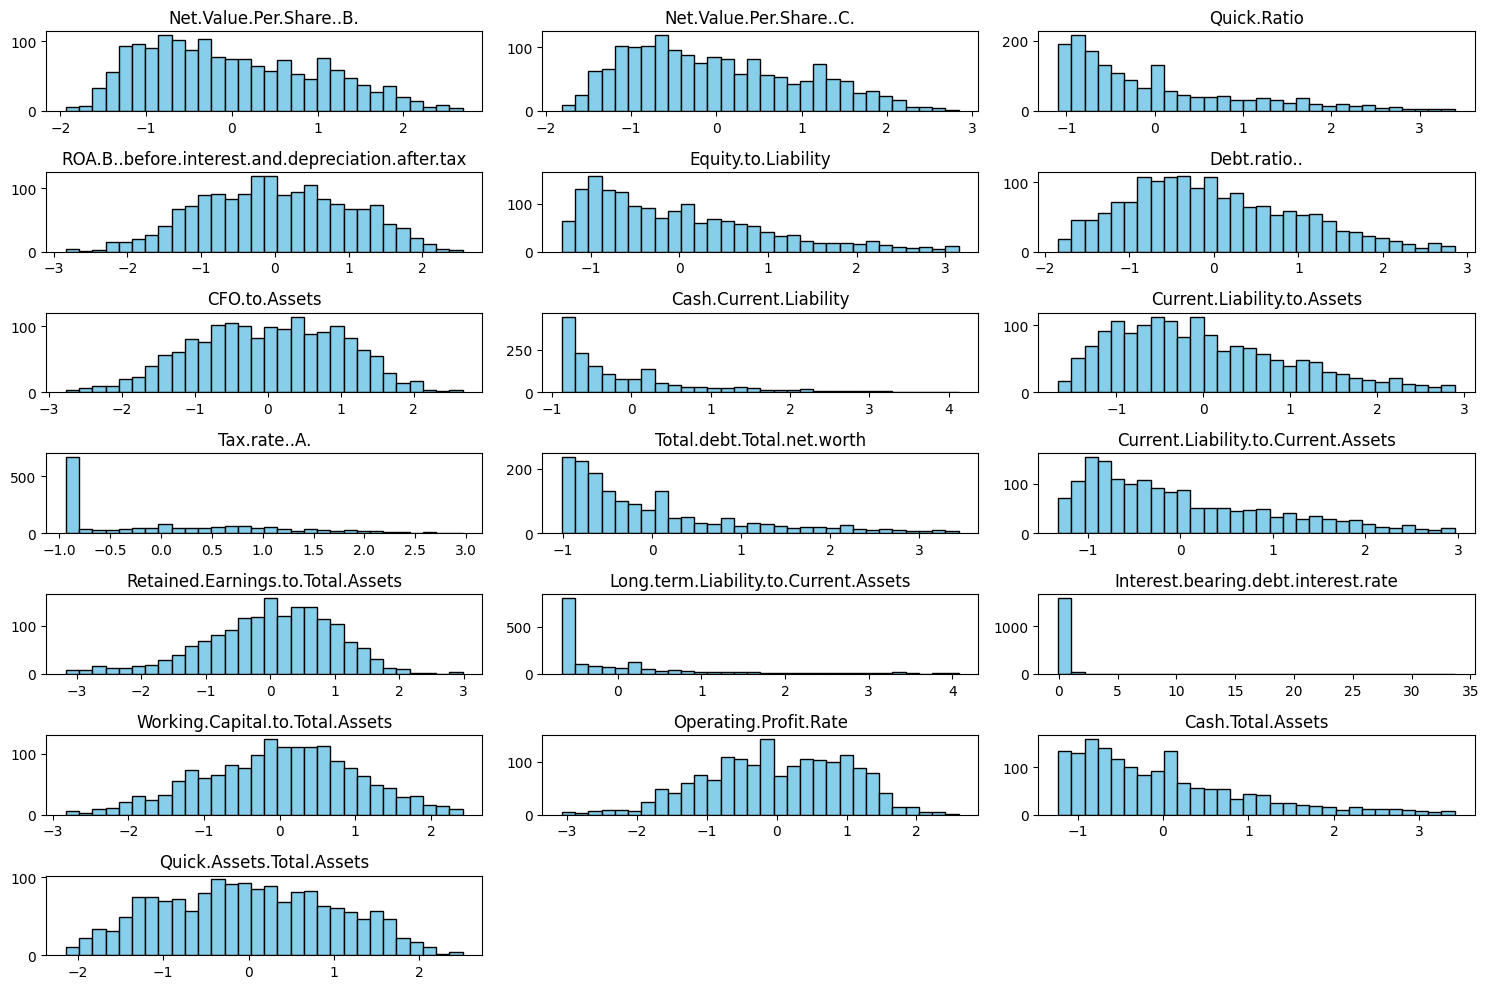

In [217]:

def plot_all_histograms(df, bins=30, figsize=(15, 10)):
    numeric_cols = df.select_dtypes(include='number').columns
    num_cols = len(numeric_cols)
    
    # Calcular filas y columnas para el grid de subplots
    n_cols = 3
    n_rows = (num_cols + n_cols - 1) // n_cols  # Redondear hacia arriba

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(col)

    # Eliminar subplots vacíos
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_all_histograms(X_train_transformed)



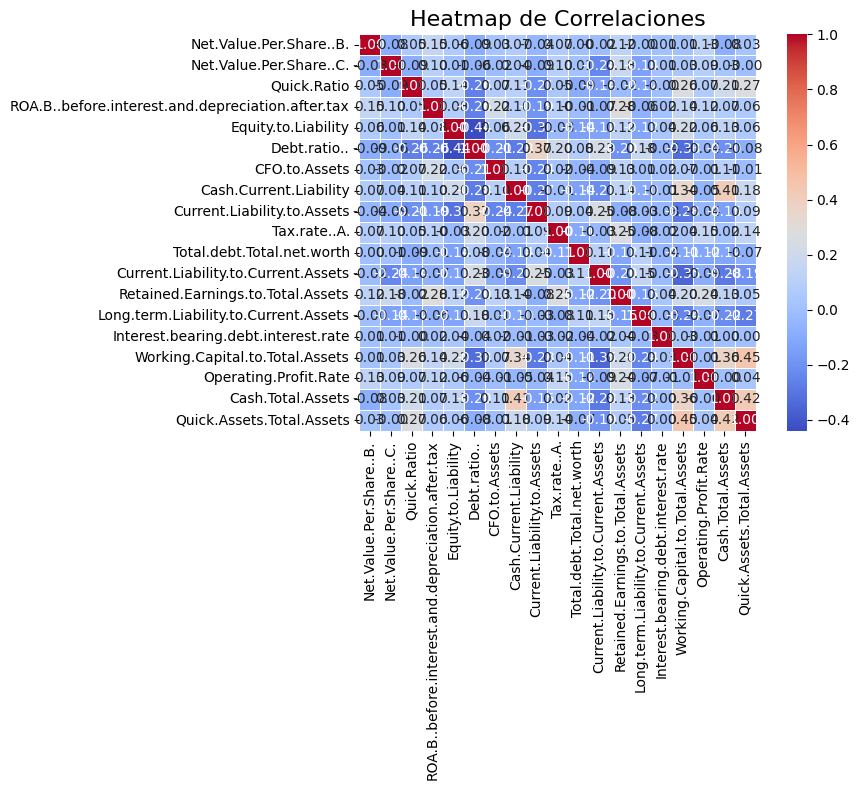

In [218]:
def plot_correlation_heatmap(df, figsize=(10, 8), cmap='coolwarm'):
    corr = df.select_dtypes(include='number').corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, square=True, linewidths=0.5)
    plt.title("Heatmap de Correlaciones", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    
plot_correlation_heatmap(X_train_transformed)


In [ ]:
# Inicializa RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Realiza el over-sampling solo sobre el conjunto de entrenamiento
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_transformed, y_train)

# Verifica el nuevo balanceo
print("Distribución antes del balanceo:", Counter(y_train))
print("Distribución después del balanceo:", Counter(y_train_balanced))

X_train_transformed = X_train_balanced.copy()
y_train = y_train_balanced.copy()


Distribución antes del balanceo: Counter({0: 1588, 1: 52})
Distribución después del balanceo: Counter({0: 1588, 1: 1588})


In [ ]:

# Define your model creation function
def create_model(batch_size=10, epochs=10, optimizer='adam', activation='relu', neurons=[16, 16]):
    model = Sequential()
    model.add(Dense(neurons[0], input_dim=X_train_transformed.shape[1], activation=activation))
    for n in neurons[1:]:
        model.add(Dense(n, activation=activation))
    model.add(Dense(1, activation='sigmoid'))  # Assuming binary classification
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model



model = KerasClassifier(build_fn=create_model, verbose=0)


param_grid = {
    'batch_size': [10, 16],
    'epochs': [8, 10, 12],
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'tanh'],
    'neurons': [[16, 16],
                [16, 8],
                [8, 8]]
}

all_results = []

# Manual grid search
for batch_size in [10, 16]:
    for epochs in [8, 10, 12]:
        for optimizer in ['adam', 'rmsprop']:
            for activation in ['relu', 'tanh']:
                for neurons in [[16, 16], [16, 8], [8, 8], [8, 8, 8]]:
                    # Create and compile model
                    model = create_model(batch_size, epochs, optimizer, activation, neurons)
                    
                    # Use cross-validation manually
                    kf = KFold(n_splits=3, shuffle=True, random_state=42)
                    cv_scores = []
                    
                    for train_idx, val_idx in kf.split(X_train_transformed):
                        # Use .iloc for pandas DataFrames
                        X_cv_train, X_cv_val = X_train_transformed.iloc[train_idx], X_train_transformed.iloc[val_idx]
                        
                        # Check if y_train is also a DataFrame/Series
                        if isinstance(y_train, (pd.DataFrame, pd.Series)):
                            y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                        else:
                            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
                        
                        # Train model
                        model.fit(X_cv_train, y_cv_train, epochs=epochs, batch_size=batch_size, verbose=0)
                        
                        # Calculate AUC instead of just accuracy
                        y_pred = model.predict(X_cv_val, verbose=0)
                        auc = roc_auc_score(y_cv_val, y_pred)
                        cv_scores.append(auc)
                    
                    # Average AUC across folds
                    mean_auc = np.mean(cv_scores)
                    params = {
                        'batch_size': batch_size,
                        'epochs': epochs,
                        'optimizer': optimizer,
                        'activation': activation,
                        'neurons': neurons
                    }
                    
                    # Store the mean AUC and parameters
                    all_results.append((mean_auc, params))
                    
                    print(f"Params: {params}, Mean AUC: {mean_auc:.4f}")

# Sort all results by AUC (descending)
all_results.sort(reverse=True)

# Get top 3 models
top_3_models = all_results[:3]

print("\nTop 3 models based on cross-validation AUC:")
for i, (auc, params) in enumerate(top_3_models, 1):
    print(f"{i}. AUC: {auc:.4f} with parameters: {params}")

# Now train these top 3 models on the full training set and evaluate on test set
print("\nTraining top 3 models on full training set and evaluating on test set:")

test_results = []
for i, (cv_auc, params) in enumerate(top_3_models, 1):
    print(f"\nTraining model {i} with parameters: {params}")
    
    # Create and train model with best parameters on full training set
    model = create_model(
        batch_size=params['batch_size'],
        epochs=params['epochs'],
        optimizer=params['optimizer'],
        activation=params['activation'],
        neurons=params['neurons']
    )
    
    # Train on full training set
    model.fit(
        X_train_transformed, y_train,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        verbose=1
    )
    
    # Evaluate on test set using AUC
    y_test_pred = model.predict(X_test_transformed, verbose=0)
    test_auc = roc_auc_score(y_test, y_test_pred)
    test_results.append((test_auc, params))
    
    print(f"Model {i} - Test AUC: {test_auc:.4f}")

# Final ranking of models based on test set AUC
print("\nFinal ranking of models based on test set AUC:")
test_results.sort(reverse=True)
for i, (auc, params) in enumerate(test_results, 1):
    print(f"{i}. Test AUC: {auc:.4f} with parameters: {params}")


Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'relu', 'neurons': [16, 16]}, Mean AUC: 0.9872
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'relu', 'neurons': [16, 8]}, Mean AUC: 0.9840
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'relu', 'neurons': [8, 8]}, Mean AUC: 0.9710
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'relu', 'neurons': [8, 8, 8]}, Mean AUC: 0.9763
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'tanh', 'neurons': [16, 16]}, Mean AUC: 0.9842
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'tanh', 'neurons': [16, 8]}, Mean AUC: 0.9849
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'tanh', 'neurons': [8, 8]}, Mean AUC: 0.9726
Params: {'batch_size': 10, 'epochs': 8, 'optimizer': 'adam', 'activation': 'tanh', 'neurons': [8, 8, 8]}, Mean AUC: 0.9799
Params: {'batch_size': 10, '

In [231]:
model1 = Sequential()
model1.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='tanh'))
model1.add(Dense(16, activation='tanh'))
model1.add(Dense(1, activation='sigmoid'))

model2 = Sequential()
model2.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='tanh'))
model2.add(Dense(16, activation='tanh'))
model2.add(Dense(1, activation='sigmoid'))

model3 = Sequential()
model3.add(Dense(16, input_dim=X_train_transformed.shape[1], activation='relu'))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

In [232]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [233]:
history1=model1.fit(X_train_transformed, y_train, epochs=12, batch_size=10 )
history2=model2.fit(X_train_transformed, y_train, epochs=10, batch_size=10 )
history3=model3.fit(X_train_transformed, y_train, epochs=12, batch_size=10 )

Epoch 1/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.7423 - loss: 0.5336
Epoch 2/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.8403 - loss: 0.3691
Epoch 3/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - accuracy: 0.8722 - loss: 0.3140
Epoch 4/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - accuracy: 0.8971 - loss: 0.2743
Epoch 5/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.9121 - loss: 0.2376
Epoch 6/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.9260 - loss: 0.2030
Epoch 7/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - accuracy: 0.9489 - loss: 0.1729
Epoch 8/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step - accuracy: 0.9562 - loss: 0.1479
Epoch 9/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - accuracy: 0.9636 - loss: 0.1270
Epoch 10/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.9711 - loss: 0.1093
Epoch 11/12
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.9765 - loss: 0.0942
Epoch 12/12
318/318 ━━━━━━━━━━

In [234]:
_, accuracy = model1.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

_, accuracy = model2.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

_, accuracy = model3.evaluate(X_test_transformed, y_test)
print('Accuracy: %.2f' % (accuracy*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.9493 - loss: 0.1661
Accuracy: 94.88
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.9332 - loss: 0.1645
Accuracy: 92.44
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9288 - loss: 0.2069 
Accuracy: 92.93


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC para el modelo 1: 0.9460
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC para el modelo 2: 0.8957
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
AUC para el modelo 3: 0.8805


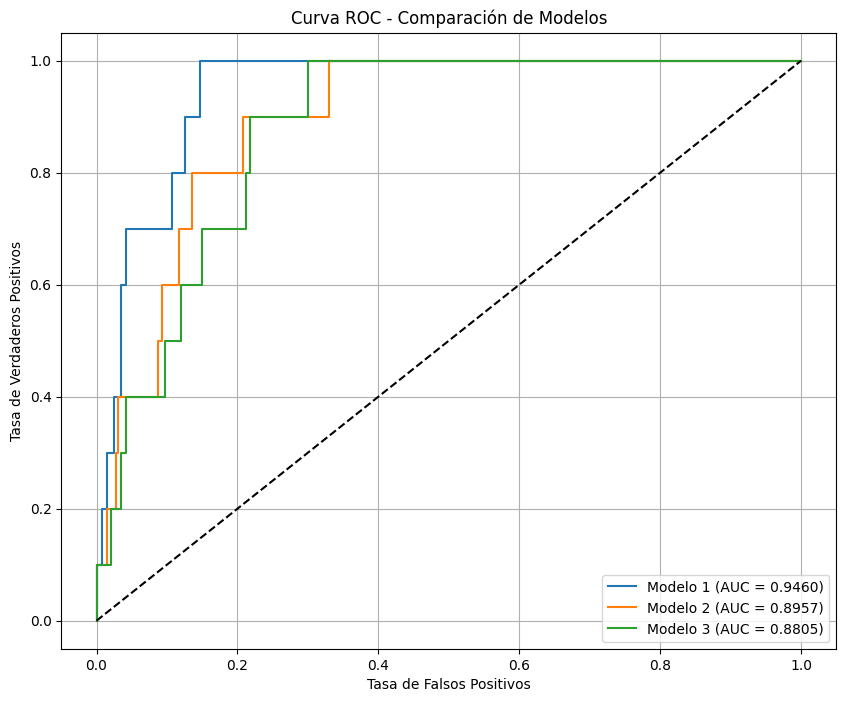

In [235]:
from sklearn.metrics import roc_auc_score, roc_curve

# Modelo 1
predicciones1_prob = model1.predict(X_test_transformed)  # Mantén las probabilidades sin redondear
auc1 = roc_auc_score(y_test, predicciones1_prob)
print(f"AUC para el modelo 1: {auc1:.4f}")

# Modelo 2
predicciones2_prob = model2.predict(X_test_transformed)
auc2 = roc_auc_score(y_test, predicciones2_prob)
print(f"AUC para el modelo 2: {auc2:.4f}")

# Modelo 3
predicciones3_prob = model3.predict(X_test_transformed)
auc3 = roc_auc_score(y_test, predicciones3_prob)
print(f"AUC para el modelo 3: {auc3:.4f}")

# También puedes visualizar las curvas ROC
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Curva ROC para modelo 1
fpr1, tpr1, _ = roc_curve(y_test, predicciones1_prob)
plt.plot(fpr1, tpr1, label=f'Modelo 1 (AUC = {auc1:.4f})')

# Curva ROC para modelo 2
fpr2, tpr2, _ = roc_curve(y_test, predicciones2_prob)
plt.plot(fpr2, tpr2, label=f'Modelo 2 (AUC = {auc2:.4f})')

# Curva ROC para modelo 3
fpr3, tpr3, _ = roc_curve(y_test, predicciones3_prob)
plt.plot(fpr3, tpr3, label=f'Modelo 3 (AUC = {auc3:.4f})')

# Línea de referencia (modelo aleatorio)
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.grid(True)
plt.show()

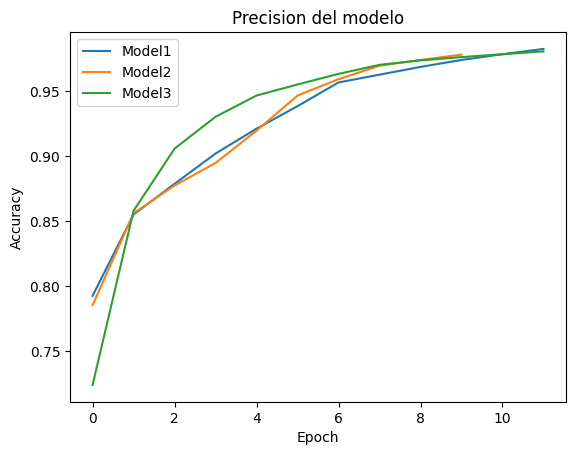

In [236]:
plt.figure(1)
# Graficar accuracy del modelo
plt.title('Precision del modelo')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.plot(history1.history['accuracy'])
plt.plot(history2.history['accuracy'])
plt.plot(history3.history['accuracy'])

plt.legend(['Model1', 'Model2', 'Model3'], loc='upper left')
plt.show()

In [237]:
test_data = pd.read_csv('data/test_data.csv')
test_data

,ID,Realized.Sales.Gross.Profit.Growth.Rate,Operating.Expense.Rate,Operating.Profit.Per.Share..Yuan...,Gross.Profit.to.Sales,Tax.rate..A.,Current.Liability.to.Liability,Continuous.Net.Profit.Growth.Rate,Long.term.Liability.to.Current.Assets,Total.assets.to.GNP.price,...,Per.Share.Net.profit.before.tax..Yuan...,Continuous.interest.rate..after.tax.,Liability.Assets.Flag,Working.Capital.to.Total.Assets,Degree.of.Financial.Leverage..DFL.,Operating.Gross.Margin,Contingent.liabilities.Net.worth,Operating.Profit.Growth.Rate,Cash.Flow.to.Liability,Quick.Assets.Total.Assets
0,5,0.055077,1.064430e-02,0.131220,0.657541,0.118122,0.771297,0.366505,0.018675,0.001246,...,0.197730,0.786381,0,0.828263,0.024649,0.645659,0.052743,0.913336,0.557402,0.360819
1,14,0.020286,6.654634e+07,0.247104,0.746134,0.000000,0.697656,0.313514,0.126093,0.006813,...,0.254563,0.850153,0,0.684968,0.075233,0.723486,0.003821,0.851428,0.584835,0.058199
2,16,0.040610,8.415991e+08,0.164832,0.718794,0.130647,0.398228,0.239002,0.122627,0.002547,...,0.186794,0.808544,0,0.888590,0.078625,0.737439,0.070270,0.832491,0.409327,0.449420
3,26,0.067641,1.344961e-04,0.153400,0.741510,0.000000,0.842550,0.348637,0.007500,0.000219,...,0.401842,0.830902,0,0.800685,0.158704,0.610681,0.012037,0.824596,0.561291,0.449031
4,28,0.017546,6.125562e-03,0.208468,0.743188,0.317456,0.387746,0.175101,0.039756,0.008112,...,0.329068,0.799609,0,0.824782,0.136387,0.637626,0.003518,0.900079,0.477007,0.395706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2518,0.037330,3.381351e+10,0.285901,0.701968,0.444407,0.918184,0.183372,0.000338,0.004595,...,0.284397,0.850451,0,0.809300,0.033507,0.758525,0.008149,0.836865,0.620500,0.453694
496,2523,0.102056,2.814351e-04,0.158274,0.771253,0.057874,0.725923,0.181533,0.040638,0.064586,...,0.371915,0.802988,0,0.794917,0.018306,0.692694,0.003946,0.865667,0.447704,0.066660
497,2529,0.013648,3.712747e-04,0.087591,0.598455,0.000000,0.650754,0.295609,0.156821,0.010683,...,0.182644,0.858830,0,0.713373,0.115433,0.631318,0.002632,0.893523,0.421889,0.280992
498,2530,0.031334,8.250494e-05,0.160728,0.759960,0.224295,1.000000,0.378352,0.000000,0.001199,...,0.390684,0.861165,0,0.785428,0.015998,0.677255,0.012348,0.865474,0.533708,0.852414


In [238]:
X_oos = test_data.iloc[:,1:]

X_oos_transformed = pipeline.transform(X_oos)

predicciones = model1.predict(X_oos_transformed)

test_data['Bankruptcy'] = predicciones

test_data[['ID', 'Bankruptcy']]

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step


,ID,Bankruptcy
0,5,0.000052
1,14,0.918801
2,16,0.000567
3,26,0.004104
4,28,0.000037
...,...,...
495,2518,0.000002
496,2523,0.245500
497,2529,0.576744
498,2530,0.071930


In [239]:
test_data[['ID', 'Bankruptcy']].to_csv('predictions/submit7_cv_ovun.csv', index=False)